In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## 1. Data Loading

Loading the loan default dataset, containing borrower demographic, financial, and credit history information used to predict loan default risk.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [14]:
df = pd.read_csv('/content/Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 2. Data Overview

Initial inspection of data structure, types, and the target variable distribution. The target column `Default` is imbalanced: approximately 88% of borrowers did not default, while only ~12% did. This imbalance will later affect model evaluation, particularly the Recall metric for the minority class.

In [15]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

(255347, 18)

In [16]:
df['Default'].value_counts(normalize=True)

,proportion
Default,
0,0.883872
1,0.116128


In [17]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


## 3. Distribution of Numerical Features

Visualizing the distribution of numerical columns (Age, Income, LoanAmount, CreditScore, DTIRatio, etc.) to check for skewness, outliers, or unusual patterns before proceeding to feature engineering.

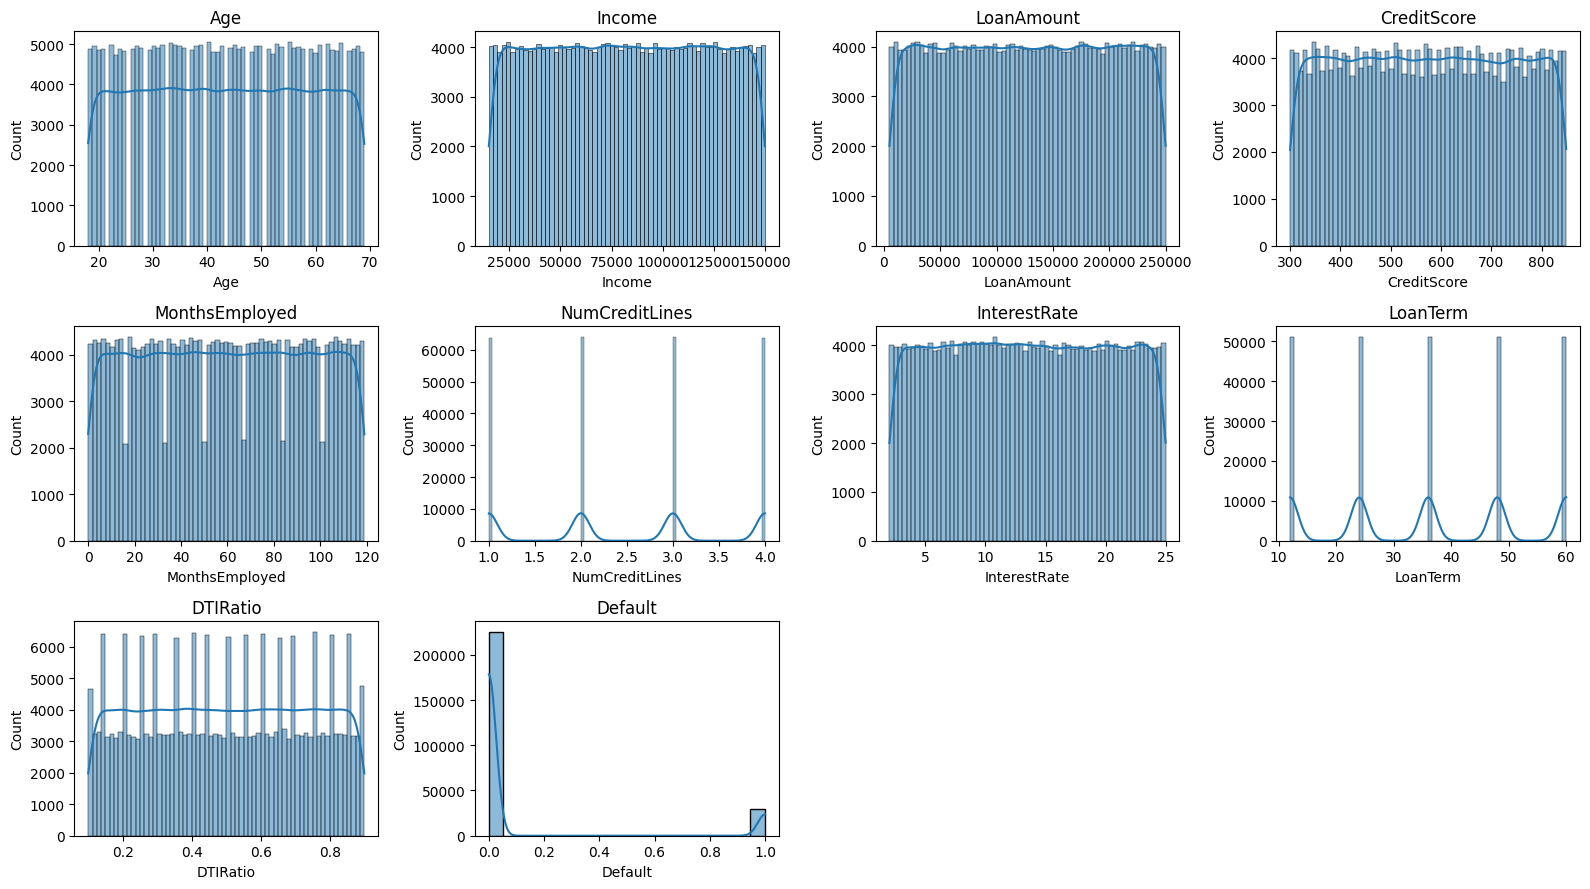

In [18]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_plots = len(num_cols)
num_cols_plot = 4
num_rows_plot = (num_plots + num_cols_plot - 1) // num_cols_plot

plt.figure(figsize=(num_cols_plot * 4, num_rows_plot * 3))

for i, col in enumerate(num_cols):
    plt.subplot(num_rows_plot, num_cols_plot, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.tight_layout()

plt.show()

## 4. Correlation Analysis

A correlation heatmap of numerical features against the target variable. Notably, none of the numerical features show strong correlation with `Default`, an early signal that this dataset may have relatively weak predictive signal for the default outcome — possibly due to its synthetic nature.

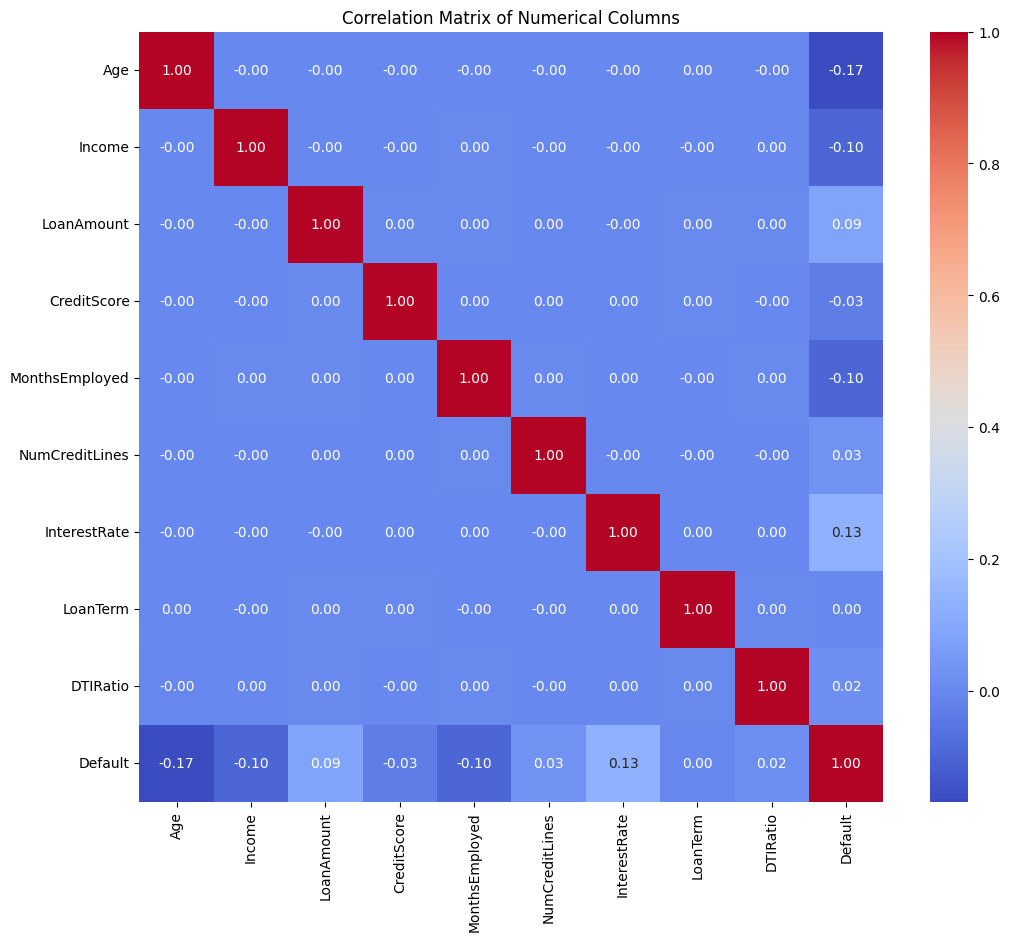

In [19]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

## 5. Feature Engineering

Three new features were engineered based on domain knowledge in credit risk:

- **EmploymentStability**: categorizes `MonthsEmployed` into risk tiers (new hire, moderately stable, highly stable)
- **CreditScoreCategory**: bins `CreditScore` into standard FICO score tiers (Poor, Fair, Good, Very Good, Excellent)
- **LoanToIncomeRatio**: combines `LoanAmount` and `Income` into a single ratio, since loan size alone is meaningless without context relative to the borrower's income

In [20]:
def categorize_employment_stability(months):
    if months < 6:
        return 'New Hire (Unstable)'
    elif months < 24:
        return 'Moderately Stable'
    else:
        return 'Highly Stable'

df['EmploymentStability'] = df['MonthsEmployed'].apply(categorize_employment_stability)
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,EmploymentStability
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,Highly Stable
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,Moderately Stable
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,Highly Stable
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,New Hire (Unstable)
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,Moderately Stable


In [21]:
def categorize_credit_score(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    elif score < 800:
        return 'Very Good'
    else:
        return 'Excellent'

df['CreditScoreCategory'] = df['CreditScore'].apply(categorize_credit_score)
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,EmploymentStability,CreditScoreCategory
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,Highly Stable,Poor
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,Moderately Stable,Poor
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,Highly Stable,Poor
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,New Hire (Unstable),Very Good
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,Moderately Stable,Fair


In [22]:
def calculate_loan_to_income(loan_amount, income):
    return loan_amount / income

df['LoanToIncomeRatio'] = calculate_loan_to_income(df['LoanAmount'], df['Income'])
df[['LoanAmount', 'Income', 'LoanToIncomeRatio']].head()

,LoanAmount,Income,LoanToIncomeRatio
0,50587,85994,0.588262
1,124440,50432,2.467481
2,129188,84208,1.534154
3,44799,31713,1.412638
4,9139,20437,0.447179


## 6. Default Rate by Category

Comparing average default rate across categories to evaluate whether the engineered features carry meaningful signal. Employment type shows the clearest separation (Unemployed borrowers default at a notably higher rate than Full-time employees), while other features show only marginal differences.

In [23]:
print(df.groupby('CreditScoreCategory')['Default'].mean())
print()
print(df.groupby('NumCreditLines')['Default'].mean())
print()
print(df.groupby('LoanPurpose')['Default'].mean())
print()
print(df.groupby('EmploymentType')['Default'].mean())

CreditScoreCategory
Excellent    0.098134
Fair         0.114321
Good         0.106289
Poor         0.124748
Very Good    0.104990
Name: Default, dtype: float64

NumCreditLines
1    0.105233
2    0.110588
3    0.119247
4    0.129424
Name: Default, dtype: float64

LoanPurpose
Auto         0.118814
Business     0.123260
Education    0.118381
Home         0.102348
Other        0.117885
Name: Default, dtype: float64

EmploymentType
Full-time        0.094634
Part-time        0.119652
Self-employed    0.114620
Unemployed       0.135529
Name: Default, dtype: float64


## 7. Visualizing Default Rate by Category

Bar charts of default rate across CreditScoreCategory, EmploymentType, LoanPurpose, and NumCreditLines to visually confirm the patterns found above.

In [24]:
def plot_default_rate(dataframe, category_col):
    grouped = dataframe.groupby(category_col)['Default'].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=grouped.index, y=grouped.values, hue=grouped.index, palette='viridis', legend=False)
    plt.title(f"Default Rate by {category_col}")
    plt.xlabel(category_col)
    plt.ylabel("Average Default Rate")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

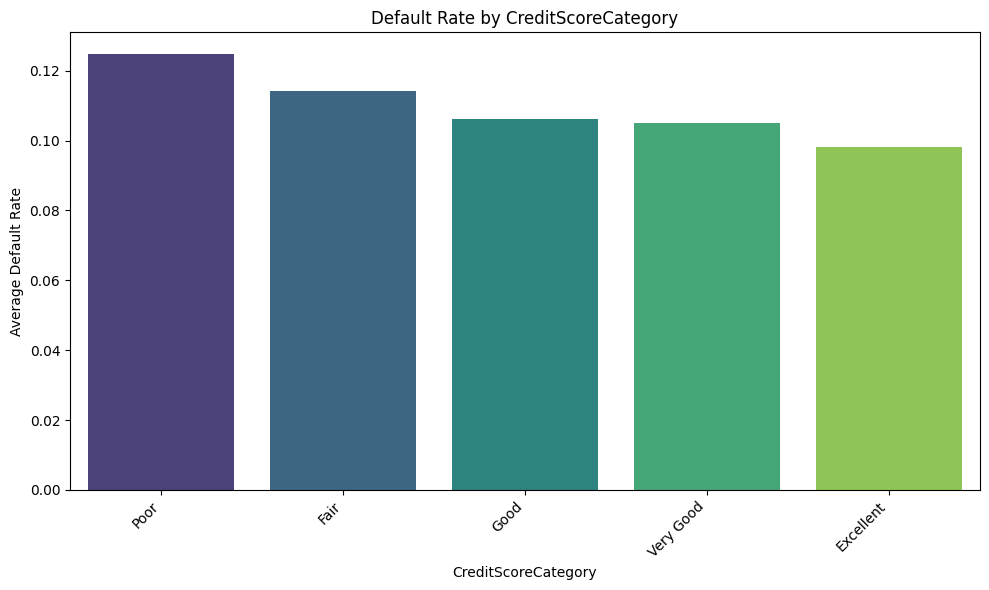

In [25]:
plot_default_rate(df, 'CreditScoreCategory')

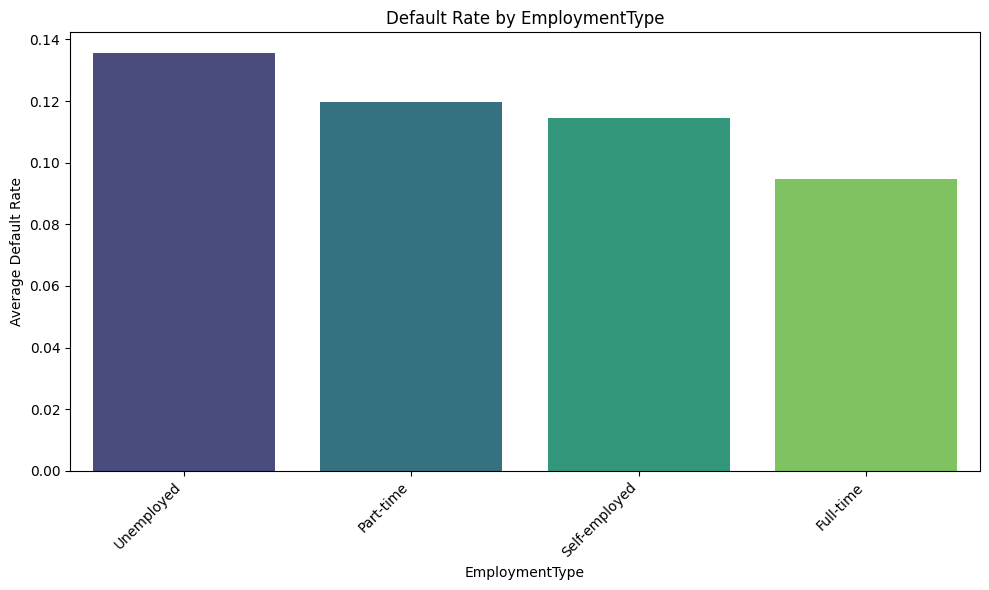

In [26]:
plot_default_rate(df, 'EmploymentType')

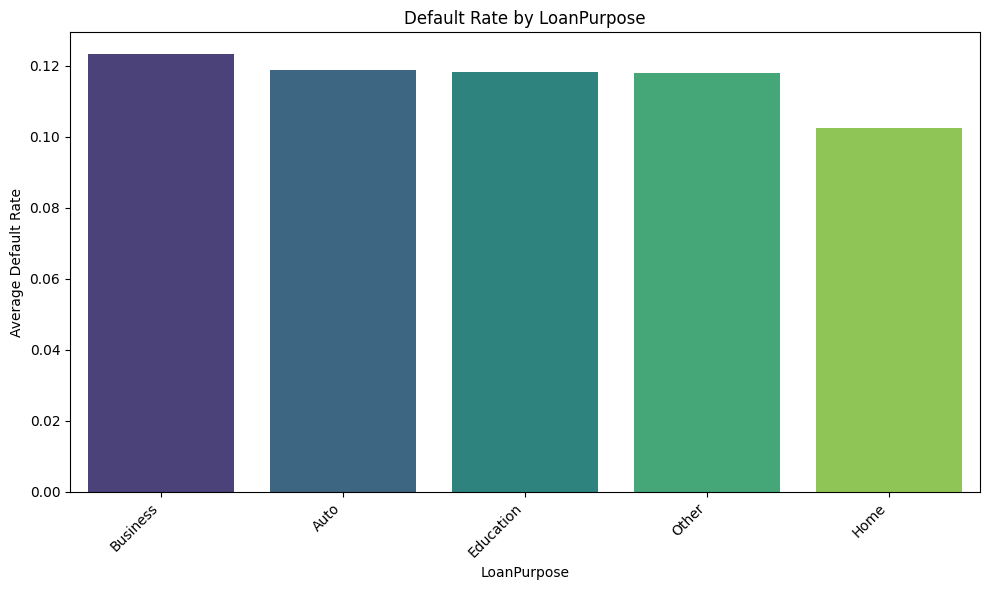

In [27]:
plot_default_rate(df, 'LoanPurpose')

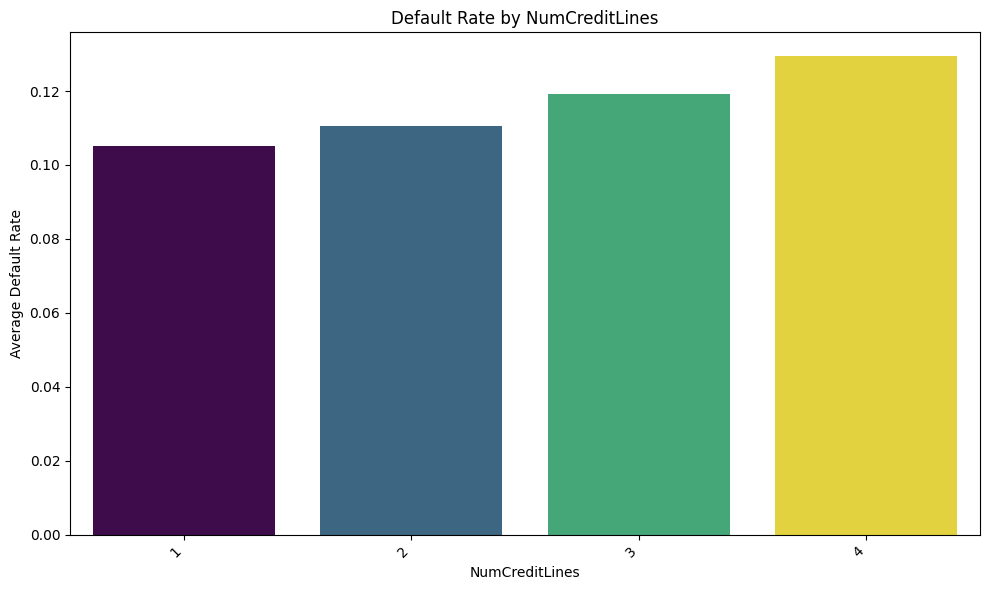

In [28]:
plot_default_rate(df, 'NumCreditLines')

## 8. Data Preparation for Modeling

Categorical features were one-hot encoded (with `drop_first=True` to avoid the dummy variable trap), then the dataset was split into training (80%) and test (20%) sets.

In [29]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y) from the raw data
X = df.drop(columns=["Default", "LoanID"])
y = df["Default"]

# 2. One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (204277, 31)
X_test shape: (51070, 31)


## 9. Model Training & Evaluation

A Logistic Regression model was trained on standardized features. Despite an overall accuracy of 89%, the Recall for the Default class is only 7% — meaning the model fails to identify the vast majority of actual default cases. This is a direct consequence of class imbalance and weak feature-target relationships, not a coding error.

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.64      0.07      0.13      5900

    accuracy                           0.89     51070
   macro avg       0.76      0.53      0.54     51070
weighted avg       0.86      0.89      0.85     51070



In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.65      0.05      0.08      5900

    accuracy                           0.89     51070
   macro avg       0.77      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45170
           1       0.20      0.23      0.21      5900

    accuracy                           0.80     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.82      0.80      0.81     51070



## 10. Confusion Matrix

Visual confirmation of the classification report: the model correctly identifies most non-default cases, but misses the majority of actual default cases (high false negative rate) — the most costly type of error in credit risk management.

<Figure size 800x600 with 0 Axes>

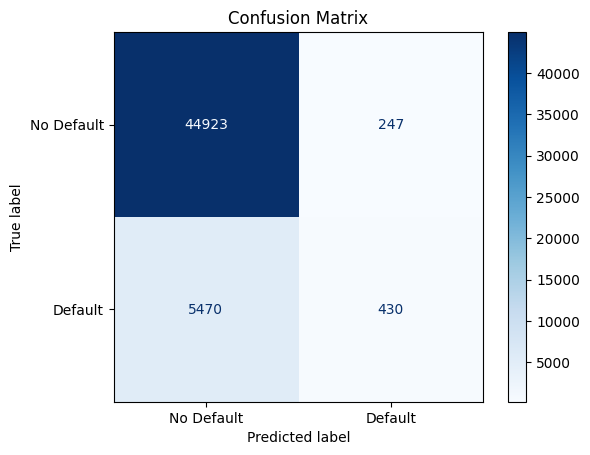

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
cmd_obj = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])

plt.figure(figsize=(8, 6))
cmd_obj.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

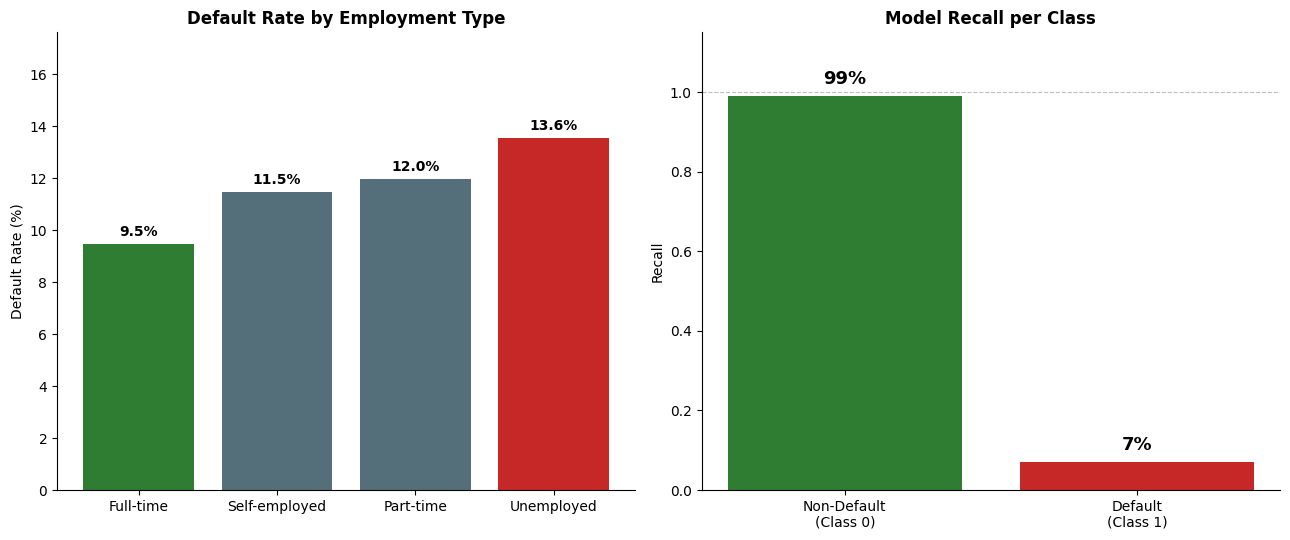

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Chart 1: Default rate by EmploymentType (fitur dengan sinyal paling kuat)
emp = df.groupby('EmploymentType')['Default'].mean().sort_values() * 100
colors1 = ['#2E7D32' if v == emp.min() else '#C62828' if v == emp.max() else '#546E7A' for v in emp.values]
bars1 = axes[0].bar(emp.index, emp.values, color=colors1)
axes[0].set_title('Default Rate by Employment Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_ylim(0, max(emp.values)*1.3)
for bar, v in zip(bars1, emp.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2: Model Recall gap between classes
categories = ['Non-Default\n(Class 0)', 'Default\n(Class 1)']
recall_vals = [0.99, 0.07]  # ganti sesuai angka classification_report lo kalau beda
colors2 = ['#2E7D32', '#C62828']
bars2 = axes[1].bar(categories, recall_vals, color=colors2)
axes[1].set_title('Model Recall per Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1.15)
for bar, v in zip(bars2, recall_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.03, f'{v:.0%}', ha='center', fontsize=13, fontweight='bold')
axes[1].axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('linkedin_summary_chart.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [35]:
# ============================================================
# SAVE LOAN DEFAULT MODELS FOR MLOPS
# ============================================================

import os
import joblib

os.makedirs("models", exist_ok=True)

print("=" * 60)
print("TRAINING AND SAVING LOAN DEFAULT MODELS")
print("=" * 60)

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

print("\nLogistic Regression")
print(classification_report(y_test, logistic_pred))

joblib.dump(
    logistic_model,
    "models/logistic_regression_model.joblib"
)

joblib.dump(
    scaler,
    "models/scaler.joblib"
)

# ------------------------------------------------------------
# 2. RANDOM FOREST
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

print("\nRandom Forest")
print(classification_report(y_test, rf_pred))

joblib.dump(
    random_forest_model,
    "models/random_forest_model.joblib"
)

# ------------------------------------------------------------
# 3. DECISION TREE
# ------------------------------------------------------------

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

dt_pred = decision_tree_model.predict(X_test)

print("\nDecision Tree")
print(classification_report(y_test, dt_pred))

joblib.dump(
    decision_tree_model,
    "models/decision_tree_model.joblib"
)

# ------------------------------------------------------------
# SAVE FEATURE INFORMATION
# ------------------------------------------------------------

feature_columns = X_encoded.columns.tolist()

joblib.dump(
    feature_columns,
    "models/feature_columns.joblib"
)

print("\n" + "=" * 60)
print("MODELS SAVED SUCCESSFULLY")
print("=" * 60)

print("models/logistic_regression_model.joblib")
print("models/random_forest_model.joblib")
print("models/decision_tree_model.joblib")
print("models/scaler.joblib")
print("models/feature_columns.joblib")

TRAINING AND SAVING LOAN DEFAULT MODELS

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.64      0.07      0.13      5900

    accuracy                           0.89     51070
   macro avg       0.76      0.53      0.54     51070
weighted avg       0.86      0.89      0.85     51070


Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.65      0.05      0.08      5900

    accuracy                           0.89     51070
   macro avg       0.77      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070


Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45170
           1       0.20      0.23      0.21      5900

    accuracy                           0.80     51070
   macro avg       0.55      0.55    

In [36]:
import os

print("Models folder:")
print(os.listdir("models"))

Models folder:
['scaler.joblib', 'feature_columns.joblib', 'decision_tree_model.joblib', 'logistic_regression_model.joblib', 'random_forest_model.joblib']


In [37]:
import shutil
import os

shutil.make_archive(
    "loan_models",
    "zip",
    "models"
)

print("Models successfully zipped!")
print(os.path.getsize("loan_models.zip"), "bytes")

Models successfully zipped!
60502022 bytes


In [38]:
from google.colab import files

files.download("loan_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This project followed the Industry Standard framework end-to-end: business understanding, data understanding, feature engineering, modeling, and evaluation.

The key takeaway is not the model's accuracy, but the honest finding that the available features (even after engineering) carry weak predictive signal for this dataset, likely due to its synthetic nature. In a real banking context, this finding would be communicated to risk management stakeholders to explore alternative data sources rather than forcing a more complex model onto insufficient signal.